# MFIS $_{t-1} \rightarrow$ MFIS $_t$

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.train import LSTMRegressionXV
from src.model import DMOTransformer
from src.core.data_transforms import Transform
from src.dataset import DMOFatigueDataset
from torch.utils.data import DataLoader
from src.train import TrainRegression
from torchmetrics.regression import R2Score


import torch

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam, AdamW

config = ModelConfig(
    name="transformer_regression",
    model_type="Transformer",
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
    
    #not used
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
)
config.notes = "None"

transformer_config = {
    "input_features": 1,
    "d_model": 32,
    "nheads": 4,
    "num_layers": 1,
    "dim_feedforward": 4*32,
    "output_size": 1,
    "dropout": 0.1
}

In [5]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [6]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [8]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [9]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

fatigue_value = dmo_labels[patient_indexs]

In [10]:
fatigue_value.shape

torch.Size([428, 4, 1])

In [11]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_value = fatigue_value / physical_subset_max

In [12]:
fatigue_value = fatigue_value.flatten(start_dim=1, end_dim=2)

In [13]:
fatigue_value.shape

torch.Size([428, 4])

In [14]:
fatigue_input = fatigue_value[:, :-1]
fatigue_input = fatigue_input.unsqueeze(dim=2)
fatigue_input = fatigue_input.flatten(start_dim=0, end_dim=1)
fatigue_input = fatigue_input.unsqueeze(dim=2)
fatigue_input.shape

torch.Size([1284, 1, 1])

In [15]:
fatigue_label = fatigue_value[:, 1:]
fatigue_label = fatigue_label.flatten(start_dim=0, end_dim=1)
fatigue_label = fatigue_label.unsqueeze(dim=1)
fatigue_label.shape

torch.Size([1284, 1])

In [16]:
# shuffle
patients, *other = fatigue_input.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

fatigue_input = fatigue_input[random_permutation]
fatigue_label = fatigue_label[random_permutation]

In [19]:
fatigue_input_split = torch.tensor_split(fatigue_input, K_FOLDS)
fatigue_label_split = torch.tensor_split(fatigue_label, K_FOLDS)

prediction_arr = []
actual_arr = []
r2_values = []

for split_i in range(K_FOLDS):
    model = DMOTransformer(**transformer_config).to(device=device)
    optimiser = config.optimiser(
        model.parameters(), lr=config.learning_rate
    )
    
    test_label = fatigue_label_split[split_i]
    test_data = fatigue_input_split[split_i]

    train_label = torch.cat(
        [fatigue_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [fatigue_input_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    transform = Transform()
    transform.fit_standard_scaler(train_data)
    train_data = transform.transform_standard_scaler(train_data)

    test_data = transform.transform_standard_scaler(test_data)
    
    # create datasets and dataloaders
    testing_dataset = DMOFatigueDataset(test_label, test_data)

    train_dataset = DMOFatigueDataset(train_label, train_data)

    test_dataloader = DataLoader(
        testing_dataset, batch_size=config.batch_size 
    )
    
    train_dataloader = DataLoader(
        train_dataset, batch_size=config.batch_size
    )
    
    trainer = TrainRegression(
        model,
        optimiser,
        config,
        train_dataloader,
        test_dataloader,
        device,
        verbose=True,
    )
    
    kwargs = {
        "label_transform": lambda x: x.view(-1),
        "pred_transform": lambda x: x.view(-1),
    }
    
    trainer.train_loop(**kwargs)
    prediction, actual = trainer.test_loop(**kwargs)
    
    prediction = torch.tensor(prediction)
    actual = torch.tensor(actual)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)
    
    # get R2 score
    r2 = R2Score()
    r2_values.append(r2(prediction, actual).item())
       
    

Testing loss: 0.019286439041881
Testing loss: 0.018615942018668112
Testing loss: 0.023898978844312403
Testing loss: 0.02372233971597298
Testing loss: 0.022828113578725606


In [20]:
prediction = torch.concatenate(prediction_arr).flatten()
prediction = (prediction * physical_subset_max).flatten()
prediction.shape

torch.Size([1284])

In [21]:
actual = torch.concatenate(actual_arr).flatten()
actual = (actual * physical_subset_max).flatten()
actual.shape

torch.Size([1284])

In [22]:
print(r2_values)

[0.5656417608261108, 0.6250649690628052, 0.5755282640457153, 0.5502133369445801, 0.5617444515228271]


All metrics: {'accuracy': 0.016355140186915886, 'Mean Squared Error': 29.321517944335938, 'Mean Absolute Error': 4.2106828689575195, 'R^2': 0.5761245489120483}


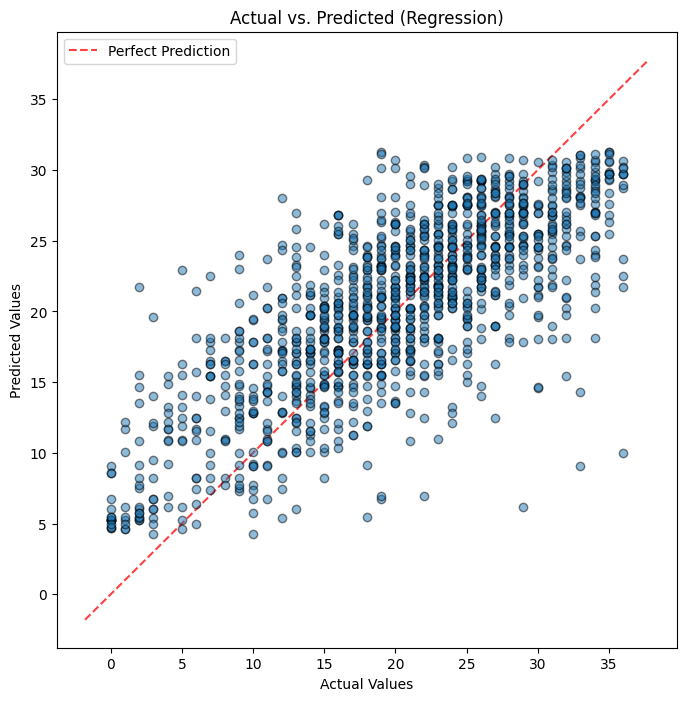

In [23]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
